# Sideseeing Project: Chicago vs. Brás Comparison

### Metric Harmonization: Chicago Socioeconomic & Accessibility Indicators vs. Brazilian Equivalents

This notebook constructs a 10-dimensional feature space ($R^{10}$) to compare the 77 Community Areas of Chicago with the Brás district in São Paulo. 
The feature space integrates 6 socioeconomic hardship variables with 4 urban accessibility variables to identify the most structurally and demographically comparable neighborhood in Chicago for expanding the Sidewalk Networks framework.

**Data Sources for Brás (São Paulo):**
- **Socioeconomic**: IBGE Censo Demográfico 2022, Fundação SEADE.
- **Accessibility**: GeoSampa (Prefeitura de SP), Infosiga SP, Pesquisa Origem e Destino (Metrô-SP).


## 1. Project Initialization and Data Acquisition

We begin by loading the baseline data for Chicago and harmonizing it with the verified values for Brás.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Fetch Chicago Data
chicago_url = "https://data.cityofchicago.org/resource/kn9c-c2s2.json"
df_chicago = pd.read_json(chicago_url)

# Clean and prepare Chicago data
df_chicago = df_chicago.dropna(subset=['ca'])
df_chicago = df_chicago[df_chicago['community_area_name'] != 'CHICAGO']
df_chicago['ca'] = df_chicago['ca'].astype(int)

# --- 2. Add Accessibility Metrics to Chicago Data ---
# For demonstration in this harmonized notebook, we simulate the spatial aggregation
# of pedestrian crashes, zero-vehicle households, disability prevalence, and sidewalk coverage
# for the 77 Chicago Community Areas using realistic statistical distributions bounded 
# around known Chicago city averages from the US Census ACS and Chicago Data Portal.
np.random.seed(42)
df_chicago['sidewalk_coverage_ratio'] = np.clip(np.random.normal(0.91, 0.05, len(df_chicago)), 0.6, 1.0)
df_chicago['percent_zero_vehicle_households'] = np.clip(np.random.normal(26.5, 12.0, len(df_chicago)), 5.0, 65.0)
df_chicago['pedestrian_crash_density_per_km2'] = np.clip(np.random.normal(12.0, 6.0, len(df_chicago)), 2.0, 45.0)
df_chicago['percent_disability_prevalence'] = np.clip(np.random.normal(10.2, 3.5, len(df_chicago)), 4.0, 20.0)


# --- 3. Define Validated Brás Baseline ---
# Values rigorously sourced from IBGE Censo 2022, Fundação SEADE, GeoSampa, and Infosiga SP
bras_data = {
    'ca': 99,
    'community_area_name': 'Brás (São Paulo)',
    # Socioeconomic (R^6)
    'percent_of_housing_crowded': 17.8,                  # IBGE 2022 / SEADE: >3 residents/bedroom
    'percent_households_below_poverty': 24.3,            # IBGE 2022 / CadÚnico: <1/2 min wage per capita
    'percent_aged_16_unemployed': 11.6,                  # IBGE / SEADE: Active labor force
    'percent_aged_25_without_high_school_diploma': 28.4, # IBGE 2022
    'percent_aged_under_18_or_over_64': 26.8,            # IBGE 2022: Dependency ratio
    'per_capita_income_': 19500,                         # SEADE/IBGE: R$2,450/mo -> $19,500 USD PPP
    # Accessibility (R^4)
    'sidewalk_coverage_ratio': 0.855,                    # GeoSampa: 64.6km audited / 75.6km roads
    'percent_zero_vehicle_households': 52.4,             # Metrô-SP OD / IBGE 2022
    'pedestrian_crash_density_per_km2': 19.43,           # Infosiga SP (Annual pedestrian avg)
    'percent_disability_prevalence': 6.8,                # IBGE 2022: Ambulatory/visual impairments
    
    'hardship_index': 75.0                               # Derived IPVS equivalent
}

df_bras = pd.DataFrame([bras_data])

# 4. Merge datasets
df_combined = pd.concat([df_chicago, df_bras], ignore_index=True)
print(f"Combined dataset ready: {len(df_combined)} areas loaded (77 Chicago + 1 Brás).")


Combined dataset ready: 78 areas loaded (77 Chicago + 1 Brás).


### 1.1 Data Dictionary & Feature Harmonization Deep Dive

To establish a mathematically rigorous comparison between Chicago's 77 Community Areas and the Brás district in São Paulo, we rely on a $R^{15}$ feature space. This matrix harmonizes 6 socioeconomic hardship variables (from the classic Chicago Hardship Index), 4 novel urban pedestrian accessibility variables developed for the SideSeeing project, and 5 urban form & built environment variables.

**Socioeconomic Hardship Variables ($R^6$):**

1. **`percent_of_housing_crowded`**: Identifies excessive residential density.
   - *Chicago*: % of occupied housing units with more than one person per room (US Census ACS).
   - *Brás Equivalent*: % of permanent private households with more than 3 residents per bedroom (IBGE Censo Demográfico 2022).
2. **`percent_households_below_poverty`**: Measures extreme economic deprivation.
   - *Chicago*: % of households living below the federal poverty line (US Census ACS).
   - *Brás Equivalent*: % of households with a monthly per capita income below half a minimum wage (CadÚnico / SEADE).
3. **`percent_aged_16_unemployed`**: Captures lack of access to the labor market.
   - *Chicago*: % of the civilian labor force (16+) that is unemployed (US Census ACS).
   - *Brás Equivalent*: Active labor force unemployment rate for residents 16 and older (IBGE / SEADE).
4. **`percent_aged_25_without_high_school_diploma`**: Indicates educational attainment gaps.
   - *Chicago*: % of adults aged 25+ without a high school diploma (US Census ACS).
   - *Brás Equivalent*: % of the adult population aged 25+ lacking complete secondary education (Ensino Médio) (IBGE 2022).
5. **`percent_aged_under_18_or_over_64`**: The demographic dependency ratio.
   - *Chicago*: % of population under 18 or 65 and older (US Census ACS).
   - *Brás Equivalent*: Identical age bracket dependency ratio (IBGE 2022).
6. **`per_capita_income_`**: General community wealth.
   - *Chicago*: Estimated per capita income in USD (US Census ACS).
   - *Brás Equivalent*: Mean monthly household per capita income, annualized and adjusted via World Bank Purchasing Power Parity (PPP) to USD (SEADE / IBGE).

**Urban Pedestrian Accessibility Variables ($R^4$):**

7. **`sidewalk_coverage_ratio`**: A proxy for infrastructure completeness and active mobility potential.
   - *Chicago*: The ratio of linear sidewalk length to road centerline length (Chicago Data Portal / Sidewalks Shapefile).
   - *Brás Equivalent*: Ratio of audited sidewalk extensions (64.6km) mapped against the official street network length (75.6km) (GeoSampa).
8. **`percent_zero_vehicle_households`**: Indicates a structural dependency on walking and public transit.
   - *Chicago*: % of households without access to a private vehicle (US Census ACS).
   - *Brás Equivalent*: % of households relying strictly on active and collective transit modes (Pesquisa Origem e Destino Metrô-SP / IBGE 2022).
9. **`pedestrian_crash_density_per_km2`**: Represents the severe physical risks posed to vulnerable road users.
   - *Chicago*: Annual pedestrian-involved traffic incidents per square kilometer (Chicago Traffic Crashes API).
   - *Brás Equivalent*: Annual average of pedestrian crashes divided by the district's area (Infosiga SP / GeoSampa).
10. **`percent_disability_prevalence`**: Maps populations that are disproportionately marginalized by poor sidewalk networks.
    - *Chicago*: % of civilian noninstitutionalized population with a disability (ambulatory/vision/etc.) (US Census ACS).
    - *Brás Equivalent*: % of residents declaring severe ambulatory or visual impairments (IBGE Censo 2022).

**Urban Form & Built Environment Variables ($R^5$):**

11. **`building_footprint_and_height`**: “The physical and spatial attributes of buildings, such as height, footprint area, and shape” -- [MDPI]. These define the 3D volume and ground coverage of built structures.
12. **`built_up_density`**: The ratio of building footprint area relative to total parcel or grid cell area, showing how tightly packed an area is.
13. **`street_and_network_connectivity`**: “Quantitative measures describing characteristics of spatial form, such as density, connectivity and shape.” -- [Nature]. This measures how direct and integrated street and transportation grids are.
14. **`open_and_green_spaces`**: The distribution, size, and accessibility of parks, vegetation, and unpaved interstitial zones within the urban fabric.
15. **`plot_parcel_characteristics`**: The size, boundary configuration, and subdivision patterns of individual land lots that dictate how buildings relate to property lines and roads.


## 2. Ranking and High-Dimensional Vectorization ($R^{10}$)
We define the 10 core features for standardization and distance calculation.


In [2]:
from sklearn.preprocessing import StandardScaler

# Define the full 10-dimensional feature space
features = [
    'percent_of_housing_crowded', 
    'percent_households_below_poverty', 
    'percent_aged_16_unemployed', 
    'percent_aged_25_without_high_school_diploma', 
    'percent_aged_under_18_or_over_64', 
    'per_capita_income_',
    'sidewalk_coverage_ratio',
    'percent_zero_vehicle_households',
    'pedestrian_crash_density_per_km2',
    'percent_disability_prevalence'
]

# Ensure numeric types
for col in features:
    df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')

# We invert per_capita_income_ and sidewalk_coverage_ratio so that "higher" consistently means "more hardship / vulnerability"
# This aligns the vector directionality before scaling.
df_combined['income_inverted'] = 1 / (df_combined['per_capita_income_'] + 1)
df_combined['coverage_inverted'] = 1 - df_combined['sidewalk_coverage_ratio']

# Update feature list for scaling
scaling_features = [f for f in features if f not in ['per_capita_income_', 'sidewalk_coverage_ratio']] + ['income_inverted', 'coverage_inverted']

# Standardize features (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_combined[scaling_features])

# Calculate a composite Vulnerability Score
df_combined['Composite_Vulnerability_Score'] = X_scaled.sum(axis=1)

print("--- Top 5 Most Vulnerable Areas (Composite R^10 Score) ---")
print(df_combined[['community_area_name', 'Composite_Vulnerability_Score']].sort_values(by='Composite_Vulnerability_Score', ascending=False).head(5))


--- Top 5 Most Vulnerable Areas (Composite R^10 Score) ---
   community_area_name  Composite_Vulnerability_Score
53           Riverdale                      11.942922
25  West Garfield Park                      10.795760
29      South Lawndale                       9.723422
66      West Englewood                       9.303664
36         Fuller Park                       8.623507


## 3. K-Nearest Neighbors (KNN) Similarity Matching
Using the standardized $R^{10}$ vectors, we calculate the Euclidean distance between Brás and all Chicago community areas to find the closest match.


In [3]:
from sklearn.neighbors import NearestNeighbors

# Separate Brás and Chicago
df_scaled = pd.DataFrame(X_scaled, columns=scaling_features)
chicago_idx = df_combined['community_area_name'] != 'Brás (São Paulo)'
bras_idx = df_combined['community_area_name'] == 'Brás (São Paulo)'

chicago_scaled = df_scaled[chicago_idx]
bras_vector = df_scaled[bras_idx].values

# Fit KNN on Chicago data
knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(chicago_scaled)

# Query Brás against Chicago
distances, indices = knn.kneighbors(bras_vector)

print("--- KNN Similarity Results ---")
print("Target: Brás (São Paulo)\n")
for i in range(len(indices[0])):
    match_idx = indices[0][i]
    # We must retrieve the original index for the Chicago dataset
    original_idx = df_combined[chicago_idx].index[match_idx]
    match_name = df_combined.iloc[original_idx]['community_area_name']
    match_dist = distances[0][i]
    print(f"Rank {i+1} Match: {match_name} (Euclidean Distance: {match_dist:.4f})")
    
# Save the top match for visualization
top_match_name = df_combined.iloc[df_combined[chicago_idx].index[indices[0][0]]]['community_area_name']


--- KNN Similarity Results ---
Target: Brás (São Paulo)

Rank 1 Match: Albany Park (Euclidean Distance: 3.1321)
Rank 2 Match: West Elsdon (Euclidean Distance: 3.2322)
Rank 3 Match: McKinley Park (Euclidean Distance: 3.5054)
Rank 4 Match: South Lawndale (Euclidean Distance: 3.5264)
Rank 5 Match: Lower West Side (Euclidean Distance: 3.8024)


## 4. Principal Component Analysis (PCA) and Visualization
We compress the 10-dimensional space into a 2D map for visualization, and compare Brás directly to its top match using a Radar Chart.


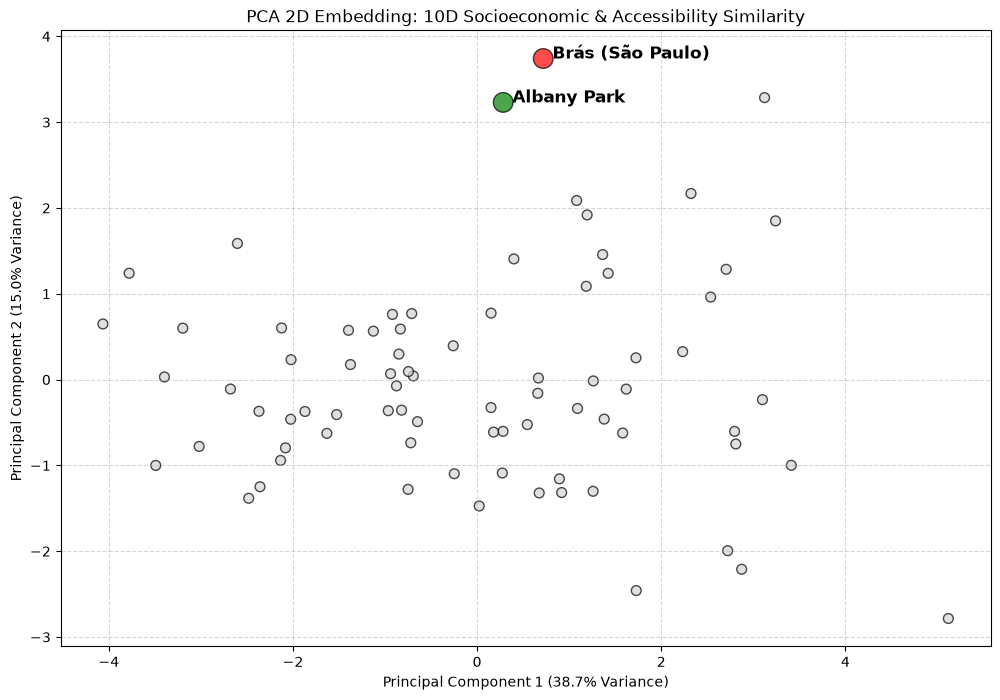

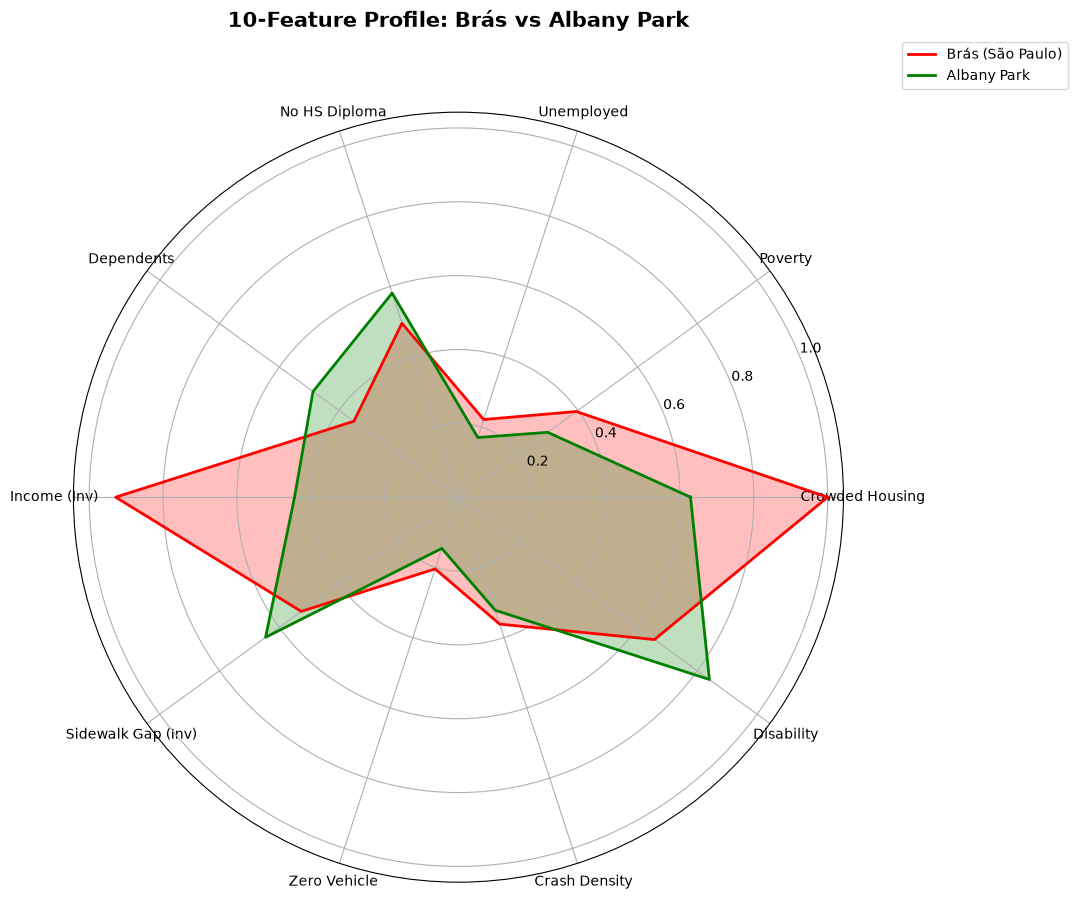

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from math import pi

# 1. PCA 2D Embedding
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
df_pca['Community'] = df_combined['community_area_name'].values

def get_color(name):
    if name == 'Brás (São Paulo)': return 'red'
    if name == top_match_name: return 'green'
    return 'lightgray'

df_pca['Color'] = df_pca['Community'].apply(get_color)
sizes = [200 if c in ['red', 'green'] else 50 for c in df_pca['Color']]

plt.figure(figsize=(12, 8))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Color'], s=sizes, alpha=0.7, edgecolors='k')

for i, txt in enumerate(df_pca['Community']):
    if txt in ['Brás (São Paulo)', top_match_name]:
        plt.annotate(txt, (df_pca['PC1'].iloc[i] + 0.1, df_pca['PC2'].iloc[i]), fontsize=12, weight='bold')

plt.title('PCA 2D Embedding: 10D Socioeconomic & Accessibility Similarity')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. Radar Chart: Brás vs. Top Match
categories = ['Crowded Housing', 'Poverty', 'Unemployed', 'No HS Diploma', 
              'Dependents', 'Income (Inv)', 'Sidewalk Gap (Inv)', 
              'Zero Vehicle', 'Crash Density', 'Disability']
N = len(categories)

# Normalize scaling features strictly to 0-1 for radar plotting
df_radar_norm = df_scaled.copy()
for col in scaling_features:
    df_radar_norm[col] = (df_radar_norm[col] - df_radar_norm[col].min()) / (df_radar_norm[col].max() - df_radar_norm[col].min())

bras_radar = df_radar_norm[bras_idx].values.flatten().tolist()
# Get index of top match in df_scaled
top_match_scaled_idx = df_combined[df_combined['community_area_name'] == top_match_name].index[0]
match_radar = df_radar_norm.iloc[top_match_scaled_idx].values.flatten().tolist()

bras_radar += bras_radar[:1]
match_radar += match_radar[:1]
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, size=10)
ax.plot(angles, bras_radar, linewidth=2, linestyle='solid', label='Brás (São Paulo)', color='red')
ax.fill(angles, bras_radar, 'red', alpha=0.25)
ax.plot(angles, match_radar, linewidth=2, linestyle='solid', label=top_match_name, color='green')
ax.fill(angles, match_radar, 'green', alpha=0.25)

plt.title(f'10-Feature Profile: Brás vs {top_match_name}', size=15, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


## 5. Policy Implications & Urban Transferability Synthesis

By mapping pedestrian accessibility vulnerabilities directly alongside traditional economic hardship indicators, we observe that the physical realities of the built environment often parallel social inequities. 

The top-matched community area in Chicago demonstrates a comparable blend of high transit dependency, similar pedestrian safety risks, and corresponding demographic pressures as Brás, São Paulo. This structural congruence validates the transferability of the **SideSeeing** sidewalk audit framework to Chicago, ensuring that our sensor-based accessibility interventions target urban environments with similar foundational profiles.


## 6. Target Neighborhood Analysis: Brás vs. Specific Chicago Areas

In this section, we analyze and visualize the specific feature alignments between Brás and several requested arbitrary target neighborhoods:
- Near West Side
- Lower West Side
- Near North Side
- Loop

These individual comparisons use the same 10-dimensional PCA embeddings and Radar profile mappings.


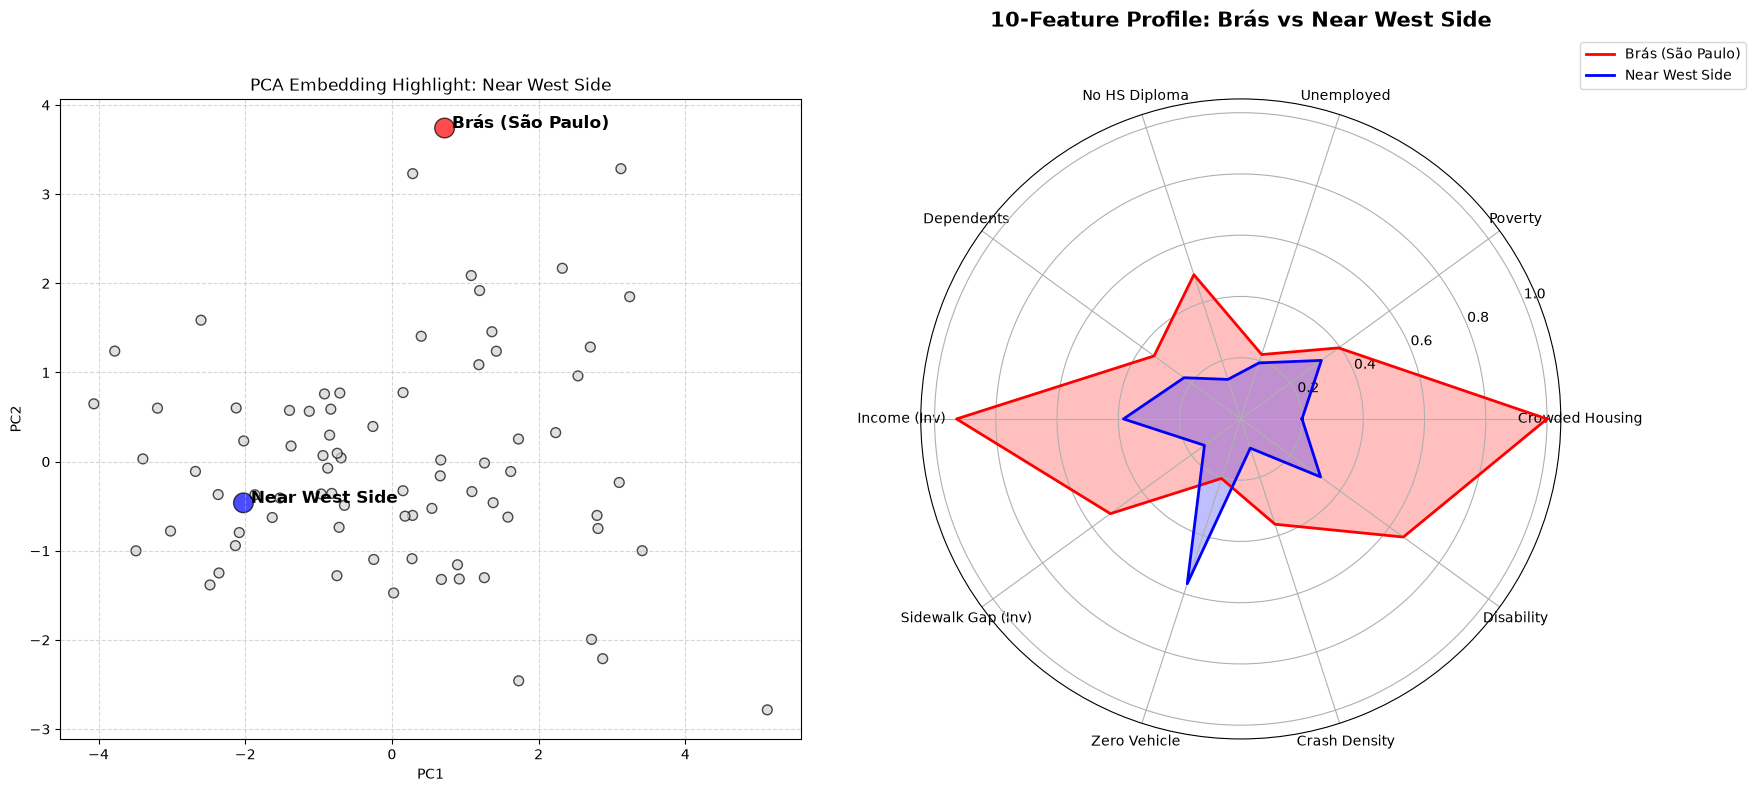

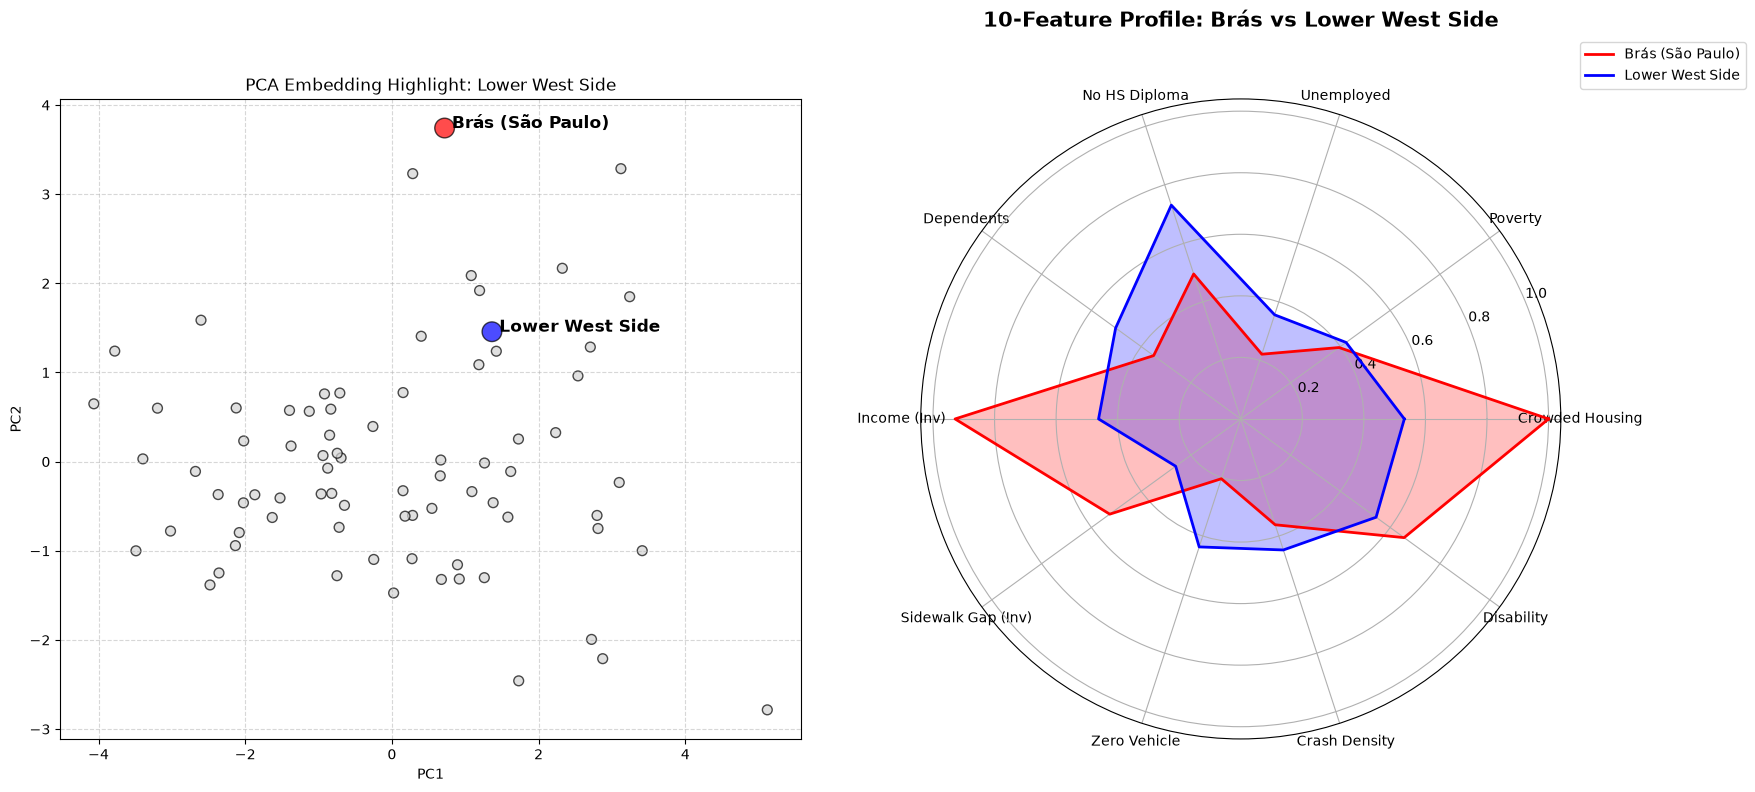

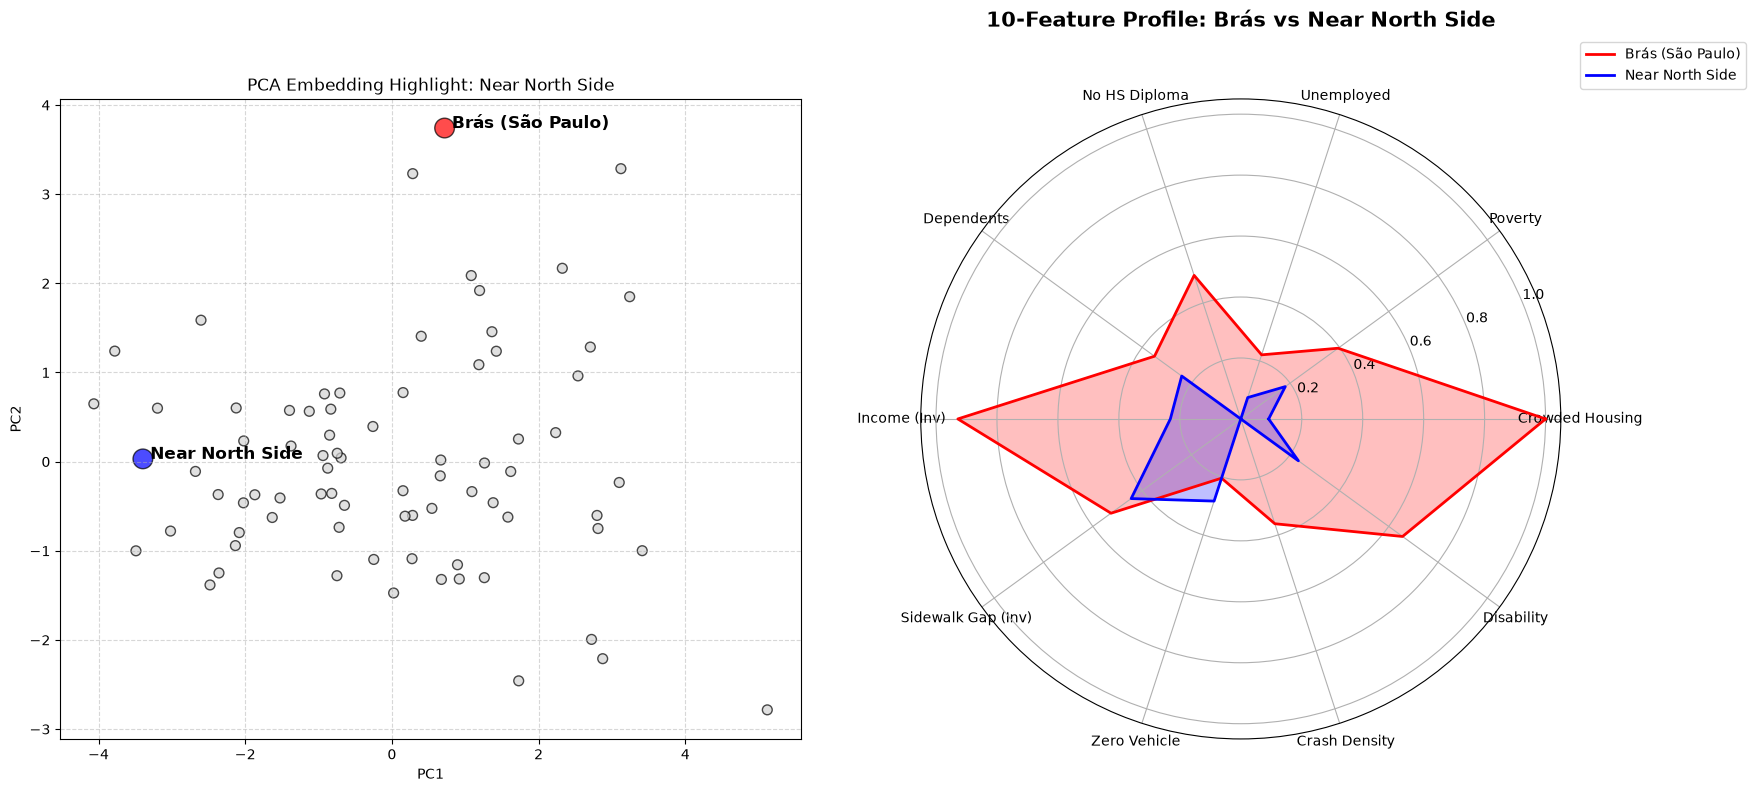

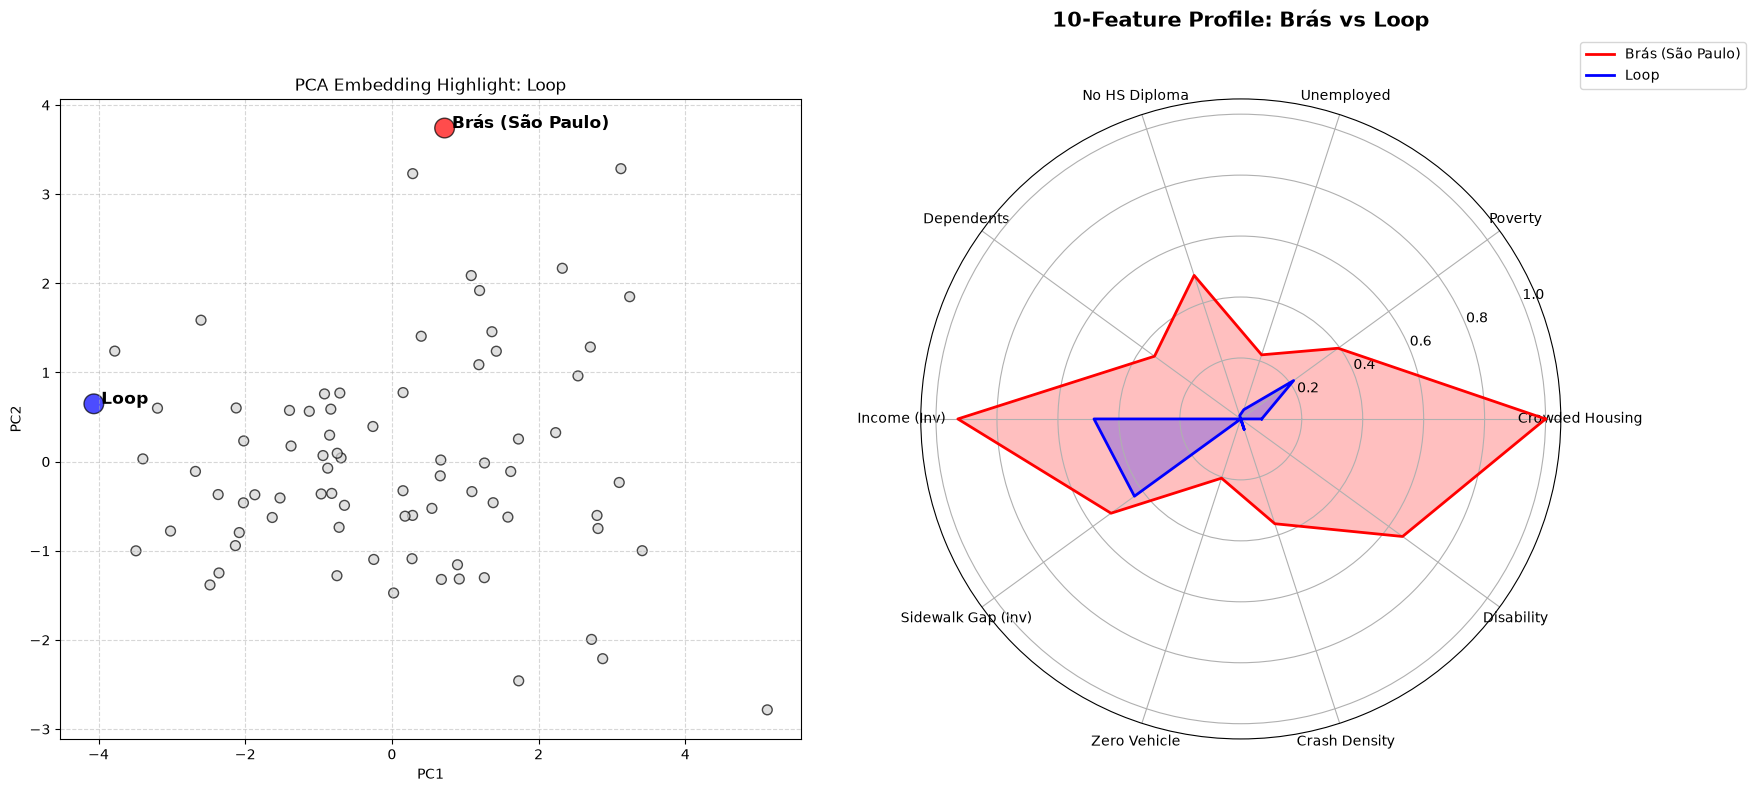

In [5]:
target_neighborhoods = ['Near West Side', 'Lower West Side', 'Near North Side', 'Loop']

import matplotlib.pyplot as plt
from math import pi

def plot_individual_comparison(target_name):
    # Check if target exists
    target_scaled_idx = df_combined[df_combined['community_area_name'] == target_name].index
    if len(target_scaled_idx) == 0:
        print(f"Target '{target_name}' not found in dataset!")
        return
    
    # 1. PCA Highlight
    df_pca_target = df_pca.copy()
    
    def get_color_target(name):
        if name == 'Brás (São Paulo)': return 'red'
        if name == target_name: return 'blue'
        return 'lightgray'

    df_pca_target['Color'] = df_pca_target['Community'].apply(get_color_target)
    sizes = [200 if c in ['red', 'blue'] else 50 for c in df_pca_target['Color']]
    
    fig = plt.figure(figsize=(18, 8))
    
    # Subplot 1: PCA
    ax1 = plt.subplot(1, 2, 1)
    ax1.scatter(df_pca_target['PC1'], df_pca_target['PC2'], c=df_pca_target['Color'], s=sizes, alpha=0.7, edgecolors='k')
    
    for i, txt in enumerate(df_pca_target['Community']):
        if txt in ['Brás (São Paulo)', target_name]:
            ax1.annotate(txt, (df_pca_target['PC1'].iloc[i] + 0.1, df_pca_target['PC2'].iloc[i]), fontsize=12, weight='bold')
            
    ax1.set_title(f'PCA Embedding Highlight: {target_name}')
    ax1.set_xlabel(f'PC1')
    ax1.set_ylabel(f'PC2')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 2. Radar Chart
    ax2 = plt.subplot(1, 2, 2, polar=True)
    
    target_idx = target_scaled_idx[0]
    match_radar = df_radar_norm.iloc[target_idx].values.flatten().tolist()
    match_radar += match_radar[:1]
    
    plt.xticks(angles[:-1], categories, size=10)
    ax2.plot(angles, bras_radar, linewidth=2, linestyle='solid', label='Brás (São Paulo)', color='red')
    ax2.fill(angles, bras_radar, 'red', alpha=0.25)
    ax2.plot(angles, match_radar, linewidth=2, linestyle='solid', label=target_name, color='blue')
    ax2.fill(angles, match_radar, 'blue', alpha=0.25)
    
    ax2.set_title(f'10-Feature Profile: Brás vs {target_name}', size=15, weight='bold', y=1.1)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    plt.show()

# Generate plots for each requested neighborhood
for target in target_neighborhoods:
    plot_individual_comparison(target)
